# Twitter Sentiment Analysis: Apple & Google Products


### Author : Stephen Mwaura

### 1. Introduction

Social media platforms generate vast amounts of customer feedback about products and services. For technology companies like Apple Inc. and Google LLC, this data offers valuable insights into public perception and highlights areas that may need improvement.

However, manually analyzing thousands of tweets is inefficient, time‑consuming, and unscalable. Therefore, the goal of this project is to build a Natural Language Processing (NLP) model capable of automatically classifying tweets as positive, negative, or neutral based on the sentiment expressed toward Apple and Google products. The resulting system will enable organizations to monitor brand sentiment in real time and make data‑driven decisions to enhance customer satisfaction and product development.

### 2.  Business Understanding

#### Problem Statement

Manually analyzing thousands of tweets is time-consuming, resource-intensive, and impractical at scale. Without automation, companies risk missing critical customer feedback, delaying responses to product issues, and failing to capitalize on positive sentiment. This project addresses the need for an automated sentiment classification system that can efficiently process large volumes of social media data.

Such a system enables organizations to:

* Monitor customer satisfaction in real time.

* Detect product issues early before they escalate.

* Measure public reaction to product launches and updates.

* Improve customer engagement strategies through data-driven insights.

#### Project Objective
To build a machine learning model that accurately predicts the sentiment (positive, negative, or neutral) of a tweet based solely on its textual content.

#### Success Criteria
The project will be considered successful if it meets the following benchmarks:

* Develop a working sentiment classifier that can process raw tweets and return reliable sentiment predictions.

* Achieve strong F1-score performance (macro F1 ≥ 0.70 for multi-class classification), balancing precision and recall across all sentiment classes.

* Generate actionable insights from social media conversations, such as identifying frequently criticized product features or tracking sentiment trends over time.

### 3. Data Understanding

The dataset was obtained from CrowdFlower via data.world and contains Twitter posts related to Apple and Google products during SXSW.
The dataset used in this project consists of 9,093 tweets discussing products from Apple Inc. and Google LLC. Each tweet is labeled according to the sentiment expressed toward a specific brand or product.
                                         |
### Dataset Variables

| Variable | Description |
|----------|-------------|
| tweet_text | The full text content of the tweet |
| emotion_in_tweet_is_directed_at | The specific product or brand mentioned (e.g., iPhone, Google Pixel) |
| is_there_an_emotion_directed_at_a_brand_or_product | The sentiment label assigned to the tweet |

### Sentiment Distribution

| Sentiment | Count | Percentage (%) |
|-----------|-------|----------------|
| No emotion toward brand or product | 5389 | 59.3 |
| Positive emotion | 2978 | 32.8 |
| Negative emotion | 570 | 6.3 |
| I can't tell | 156 | 1.7 |
| **Total** | **9093** | **100.0** |

#### Key Observation
The dataset is highly imbalanced. The majority class ("no emotion") accounts for nearly 60% of all tweets, while negative sentiment represents only about 6% of the data.

Because of this imbalance, accuracy would be a misleading performance metric. A naive model predicting only "no emotion" would achieve high accuracy but fail to detect meaningful positive or negative feedback. Therefore, F1-score (macro or weighted) is selected as the primary evaluation metric, as it balances precision and recall across all classes, especially the minority classes

### Import the Required Libraries

In [67]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import re
from collections import Counter
from nltk.corpus import stopwords, wordnet
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Stephen\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Stephen\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Stephen\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### Loading the dataset

In [15]:
# Load the dataset and display the first few rows
df = pd.read_csv('Twitter_Sentiment_Data.csv', encoding='latin-1')
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [17]:
# Rename columns for clarity and consistency
df.rename(columns={
    'tweet_text': 'tweet',
    'emotion_in_tweet_is_directed_at': 'target_brand',
    'is_there_an_emotion_directed_at_a_brand_or_product': 'sentiment'
}, inplace=True)

## Exploratory Data Analysis

5. Exploratory Data Analysis

Exploratory Data Analysis (EDA) was conducted to understand the underlying structure, class balance, and linguistic patterns within the dataset. These insights guided subsequent preprocessing and modeling decisions.

Key Findings
* Positive tweets significantly outnumber negative tweets	Indicates generally favorable public sentiment toward Apple and Google products
* Neutral tweets dominate the dataset	Highlights class imbalance; accuracy alone would be misleading
* Apple and Google products are frequently mentioned across tweets	Confirms the dataset's relevance and focus for the business problem

Visualizations:
To better understand the data, the following visualization was created:
* Sentiment distribution chart	Displays class imbalance visually and confirms data quality

In [18]:
# Explore the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   tweet         9092 non-null   str  
 1   target_brand  3291 non-null   str  
 2   sentiment     9093 non-null   str  
dtypes: str(3)
memory usage: 213.2 KB


In [19]:
# Check for missing values
df.isnull().sum()

tweet              1
target_brand    5802
sentiment          0
dtype: int64

In [20]:
# Check for duplicates
df.duplicated().sum()

np.int64(22)

In [21]:
# Check the distribution of sentiments
df['sentiment'].value_counts()

sentiment
No emotion toward brand or product    5389
Positive emotion                      2978
Negative emotion                       570
I can't tell                           156
Name: count, dtype: int64

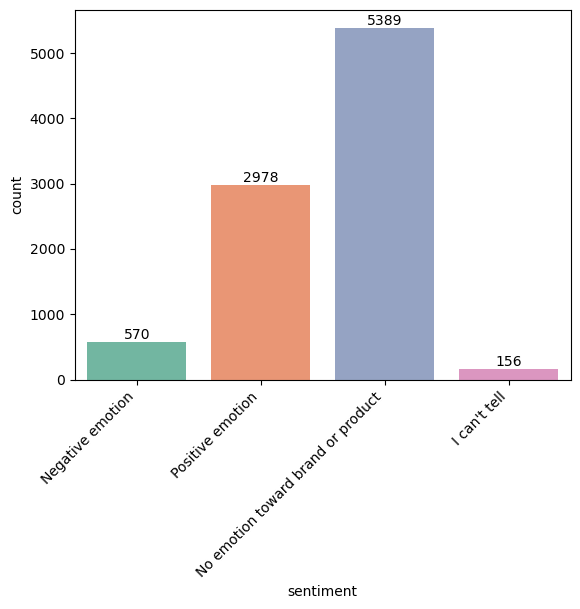

In [22]:
# Visualize the distribution of sentiment labels
ax = sns.countplot(
    data=df,
    x='sentiment',
    hue='sentiment',
    palette='Set2',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45, ha='right')

plt.show()

In [23]:
# Check the distribution of target brands
df['target_brand'].value_counts()

target_brand
iPad                               946
Apple                              661
iPad or iPhone App                 470
Google                             430
iPhone                             297
Other Google product or service    293
Android App                         81
Android                             78
Other Apple product or service      35
Name: count, dtype: int64

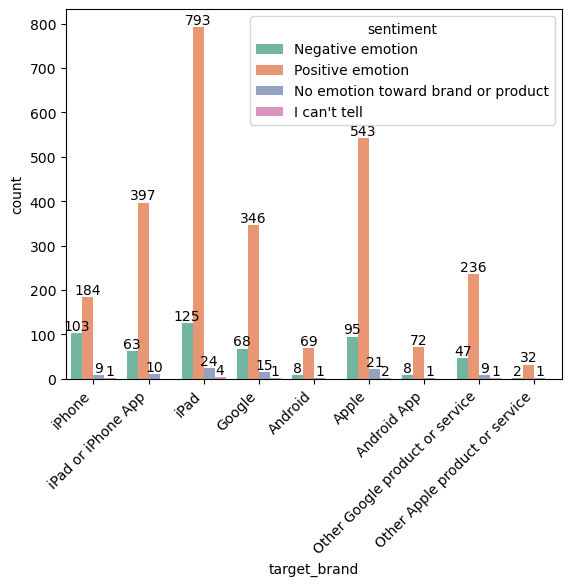

In [24]:
# Visualize the distribution of target brands
ax = sns.countplot(
    data=df,
    x='target_brand',
    hue='sentiment',
    palette='Set2'
)
for container in ax.containers:
    ax.bar_label(container)
plt.xticks(rotation=45, ha='right')
plt.show()

In [25]:
# Check the frequency of words in the tweets
all_words = ' '.join(df['tweet'].dropna()).split()

word_counts = Counter(all_words)

top_words = pd.DataFrame(
    word_counts.most_common(10),
    columns=['Word', 'Frequency']
)

top_words

,Word,Frequency
0,@mention,6703
1,{link},4255
2,#sxsw,4013
3,the,3887
4,#SXSW,3643
5,to,3496
6,RT,2883
7,at,2842
8,for,2432
9,a,2158


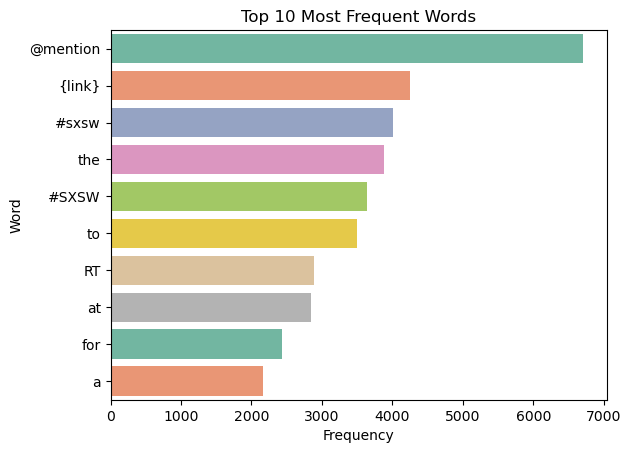

In [26]:
ax = sns.barplot(
    data=top_words,
    x='Frequency',
    y='Word',
    hue='Word',
    palette='Set2'
)

plt.title('Top 10 Most Frequent Words')
plt.show()

### 4. Data Preparation and cleaning
To prepare the raw tweet text for machine learning analysis, a systematic preprocessing pipeline was applied. These steps help reduce noise, standardize the text, and improve model performance.

#### Cleaning Process

The following preprocessing steps were applied sequentially to each tweet:

* Records with missing values were removed from the dataset.
* Text data was cleaned by eliminating stop words to reduce noise and improve model performance.
* Entries labeled as "I can't tell" were excluded, as they do not provide a clear sentiment classification. These ambiguous responses introduce uncertainty into the dataset and may negatively impact model performance by making it unclear whether they should be interpreted as positive, negative, or neutral. Since they represent only a small portion of the data, removing them helps improve dataset clarity, consistency, and the overall reliability of sentiment analysis results.
* The target_brand variable was consolidated into two main categories: Apple and Google brands, to simplify analysis and ensure a more structured comparison between the two groups.

#### Text Preprocessing Pipeline

| Step | Operation | Description |
|------|-----------|-------------|
| 1 | Convert to lowercase | Ensures uniformity by standardizing letter casing. |
| 2 | Remove URLs | Eliminates hyperlinks that carry little semantic value. |
| 3 | Remove Twitter usernames | Strips out mentions (e.g., `@username`) to focus on content. |
| 4 | Remove punctuation and special characters | Retains only letters and spaces for cleaner tokenization. |
| 5 | Remove stopwords | Filters out common words (e.g., "the", "and") that do not contribute meaning. |
| 6 | Apply lemmatization | Reduces words to their base or dictionary form (e.g., "running" → "run"). |)

#### Outcome
After preprocessing, each tweet was transformed into a clean, standardized text string suitable for vectorization (i.e, TF-IDF). This pipeline significantly reduced vocabulary size and noise, leading to more efficient and accurate sentiment classification.

In [27]:
# Drop rows with missing tweets
df = df.dropna(subset=['tweet'])

In [28]:
# Check missing values again
df.isnull().sum()

tweet              0
target_brand    5801
sentiment          0
dtype: int64

In [30]:
# Remove duplicates and check whether they are removed
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [109]:
# Fill missing values in 'target_brand' with 'unknown'
df['target_brand'] = df['target_brand'].fillna('unknown')

In [110]:
# Remove the I cant tell sentiment category
df = df[df['sentiment'] != "I can't tell"].copy()

In [111]:
# Check the distribution of sentiments again after removing "I can't tell"
print(df['sentiment'].value_counts())

print("\nPercentages:")
print(df['sentiment'].value_counts(normalize=True) * 100)

sentiment
No emotion toward brand or product    5375
Positive emotion                      2970
Negative emotion                       569
Name: count, dtype: int64

Percentages:
sentiment
No emotion toward brand or product    60.298407
Positive emotion                      33.318376
Negative emotion                       6.383217
Name: proportion, dtype: float64


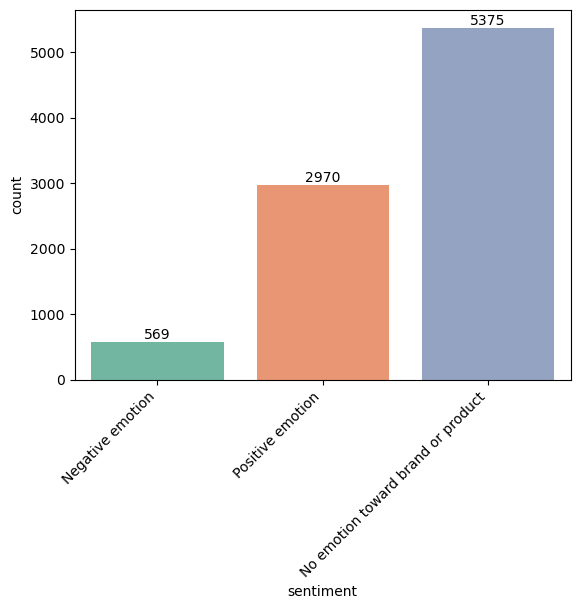

In [112]:
# Visualize the distribution of Sentiment Labels after removing "I can't tell"
ax = sns.countplot(
    data=df,
    x='sentiment',
    hue='sentiment',
    palette='Set2',
    legend=False
)
for container in ax.containers:
    ax.bar_label(container)
plt.xticks(rotation=45, ha='right')
plt.show()

In [114]:
# Merge target_brand into only two categories: apple and google brands
Apple = [
    'ipad',
    'apple',
    'iphone',
    'ipad or iphone app',
    'other apple product or service'
]

Google = [
    'google',
    'other google product or service',
    'android',
    'android app'
]

def merge_brands(brand):
    if pd.isna(brand):
        return None

    brand = str(brand).lower()

    if brand in Apple:
        return 'apple'
    elif brand in Google:
        return 'google'
    else:
        return 'other'

df['target_brand'] = df['target_brand'].apply(merge_brands)

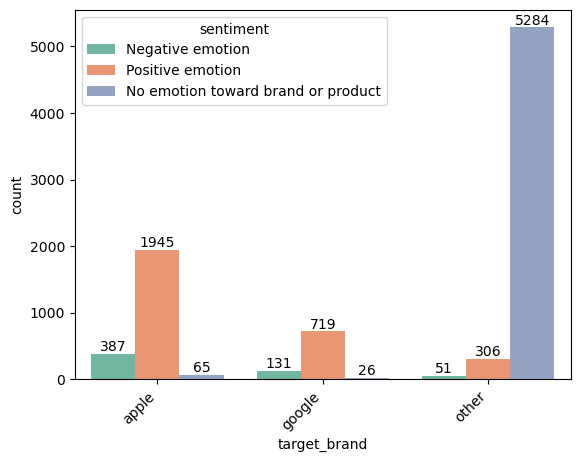

In [115]:
# Visualize the distribution of target brands
ax = sns.countplot(
    data=df,
    x='target_brand',
    hue='sentiment',
    palette='Set2'
)
for container in ax.containers:
    ax.bar_label(container)
plt.xticks(rotation=45, ha='right')
plt.show()

In [116]:
# Text preprocessing to clean the tweets

stop_words = set(ENGLISH_STOP_WORDS)
custom_stopwords = {'sxsw', 'amp', 'rt', 'just', 'new', 'today', 'via'}

# Emoji pattern
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002700-\U000027BF"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
)

def clean_tweet(text):
    text = str(text).lower()

    # Remove URLs and placeholders
    text = re.sub(r'http\S+|\{link\}', '', text)

    # Remove HTML artifacts
    text = re.sub(r'&amp;', '', text)

    # Remove mentions and hashtags symbol
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)

    # Remove emojis
    text = emoji_pattern.sub('', text)

    # Remove punctuation / non-letters
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize and filter words
    words = text.split()
    words = [
        w for w in words
        if w not in stop_words
        and w not in custom_stopwords
        and len(w) > 2
    ]

    return ' '.join(words)

df['clean_tweet'] = df['tweet'].apply(clean_tweet)

In [117]:
# Check the cleaned tweets and the frequency of words again
from collections import Counter

all_words = ' '.join(df['clean_tweet']).split()
word_counts = Counter(all_words)

freq_df = pd.DataFrame(word_counts.most_common(10), columns=['Word', 'Frequency'])
freq_df

,Word,Frequency
0,ipad,2832
1,google,2280
2,apple,2109
3,iphone,1485
4,store,1444
5,austin,936
6,app,807
7,launch,637
8,social,625
9,circles,605


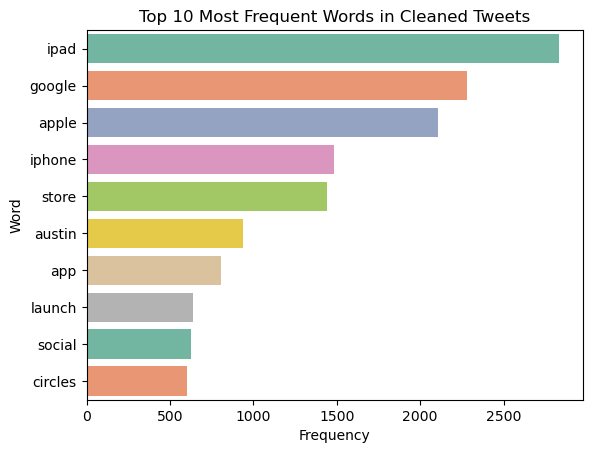

In [118]:
# Visualize the frequency of the top 10 words in the cleaned tweets
ax = sns.barplot(
    data=freq_df,
    x='Frequency',
    y='Word',
    hue='Word',
    palette='Set2'
)
plt.title('Top 10 Most Frequent Words in Cleaned Tweets')
plt.show()


In [119]:
# Preprocess the tweet column and create a new column for cleaned tweets
df['clean_tweet'] = df['tweet'].astype(str)

#### Model 1: Logistic Regression

Logistic Regression was selected as the baseline model because:

It performs well on sparse text data.
It is computationally efficient.
It provides interpretable results.

#### Model 2: Multinomial Naive Bayes

Naive Bayes is commonly used in text classification due to its simplicity and speed.

#### Model 3: Support Vector Machine (SVM)

Linear SVM is effective for high-dimensional text data and often produces strong classification performance.

#### 1. Logistic Regression

In [120]:
# Define features and target variable
X = df[['clean_tweet', 'target_brand']]
y = df['sentiment']  

In [121]:
# Split the data into training and testing sets with stratification to maintain class distribution, a test size of 20%, 
# and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [122]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=5000, stop_words='english'), 'clean_tweet'),
        ('brand', OneHotEncoder(handle_unknown='ignore'), ['target_brand'])
    ]
)

In [123]:
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])

In [124]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('brand', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [125]:
y_pred = model.predict(X_test)

In [126]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9068984856982614

Classification Report:

                                    precision    recall  f1-score   support

                  Negative emotion       0.89      0.21      0.34       114
No emotion toward brand or product       0.94      0.98      0.96      1075
                  Positive emotion       0.85      0.90      0.87       594

                          accuracy                           0.91      1783
                         macro avg       0.89      0.70      0.73      1783
                      weighted avg       0.91      0.91      0.89      1783



Although the model achieved a high overall accuracy of 91%, performance varied significantly across classes. The model performed well on the majority class (“No emotion toward brand or product”) and the positive class, but showed poor recall for the negative class (0.21), indicating difficulty in correctly identifying negative sentiments. This suggests the presence of class imbalance, which biased the model toward majority class predictions.

In [148]:
# Class imbalance handling with class_weight='balanced'
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [149]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('brand', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [150]:
y_pred = model.predict(X_test)

In [151]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8990465507571509

Classification Report:

                                    precision    recall  f1-score   support

                  Negative emotion       0.50      0.58      0.54       114
No emotion toward brand or product       0.94      0.98      0.96      1075
                  Positive emotion       0.91      0.81      0.86       594

                          accuracy                           0.90      1783
                         macro avg       0.78      0.79      0.79      1783
                      weighted avg       0.90      0.90      0.90      1783



The unbalanced logistic regression model achieved high overall accuracy (0.91) but demonstrated poor sensitivity to the minority class, with only 0.21 recall for negative emotion. This indicates a strong bias toward the majority class. Introducing class weighting improved class balance at the cost of reduced precision, but significantly increased recall for negative sentiment, making the model more suitable for real-world sentiment monitoring tasks where detecting negative opinions is critical.

### Multinomial Naive Bayes 

In [93]:
# Train a Multinomial Naive Bayes model
model_nb = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', MultinomialNB())
])

In [94]:
# Fit the Multinomial Naive Bayes model
model_nb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('brand', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [153]:
# Predict with the Multinomial Naive Bayes model
y_pred = model_nb.predict(X_test)

In [154]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8401570386988222
                                    precision    recall  f1-score   support

                  Negative emotion       1.00      0.01      0.02       114
No emotion toward brand or product       0.95      0.88      0.91      1075
                  Positive emotion       0.70      0.93      0.80       594

                          accuracy                           0.84      1783
                         macro avg       0.88      0.61      0.58      1783
                      weighted avg       0.87      0.84      0.82      1783

[[  1   9 104]
 [  0 947 128]
 [  0  44 550]]


* The model is basically ignoring the Negative class completely
* precision = 1.00 (only 1 prediction happened and it was correct)
* recall = 0.01 (it almost never detects negatives)

### 3. LinearSVC

In [127]:
# LinearSVC with class_weight='balanced' to handle class imbalance
model_Ls = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(class_weight='balanced'))
])

In [128]:
model_Ls.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('brand', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [129]:
y_pred = model_Ls.predict(X_test)

In [130]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9040942232192933

Classification Report:

                                    precision    recall  f1-score   support

                  Negative emotion       0.59      0.47      0.53       114
No emotion toward brand or product       0.94      0.97      0.96      1075
                  Positive emotion       0.88      0.86      0.87       594

                          accuracy                           0.90      1783
                         macro avg       0.81      0.77      0.78      1783
                      weighted avg       0.90      0.90      0.90      1783



### Hyperparameter Tuning of LinearSVC

In [131]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LinearSVC(class_weight='balanced'))
])

In [132]:
param_grid = {
    'preprocessor__text__ngram_range': [(1,1), (1,2)],
    'preprocessor__text__max_features': [5000, 8000, 10000],
    'preprocessor__text__min_df': [1, 2, 5],
    'clf__C': [0.1, 1, 10]
}

In [133]:
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=3,
    scoring='f1_macro',   # IMPORTANT for imbalance
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 54 candidates, totalling 162 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.1, 1, ...], 'preprocessor__text__max_features': [5000, 8000, ...], 'preprocessor__text__min_df': [1, 2, ...], 'preprocessor__text__ngram_range': [(1, ...), (1, ...)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more m

In [134]:
best_model = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'clf__C': 1, 'preprocessor__text__max_features': 8000, 'preprocessor__text__min_df': 1, 'preprocessor__text__ngram_range': (1, 1)}


In [135]:
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9057767807066741

Classification Report:

                                    precision    recall  f1-score   support

                  Negative emotion       0.63      0.45      0.52       114
No emotion toward brand or product       0.94      0.97      0.96      1075
                  Positive emotion       0.88      0.87      0.87       594

                          accuracy                           0.91      1783
                         macro avg       0.82      0.76      0.78      1783
                      weighted avg       0.90      0.91      0.90      1783



* GridSearchCV was used to optimize both TF-IDF vectorization parameters and the Linear SVM classifier. The model was evaluated using macro-averaged F1-score to account for class imbalance, ensuring that minority classes such as negative sentiment were not ignored.
* The tuned LinearSVC model achieves a strong overall accuracy of 90.6%, with a macro F1-score of 0.78, indicating reasonably balanced performance across classes. The model performs exceptionally well on the majority class (No emotion), while also maintaining strong performance on positive sentiment. Although negative sentiment remains the most challenging class, recall has improved significantly compared to the baseline model, indicating better sensitivity to minority class patterns without excessively sacrificing precision. This suggests that the model achieves a practical balance between robustness and fairness in sentiment classification.

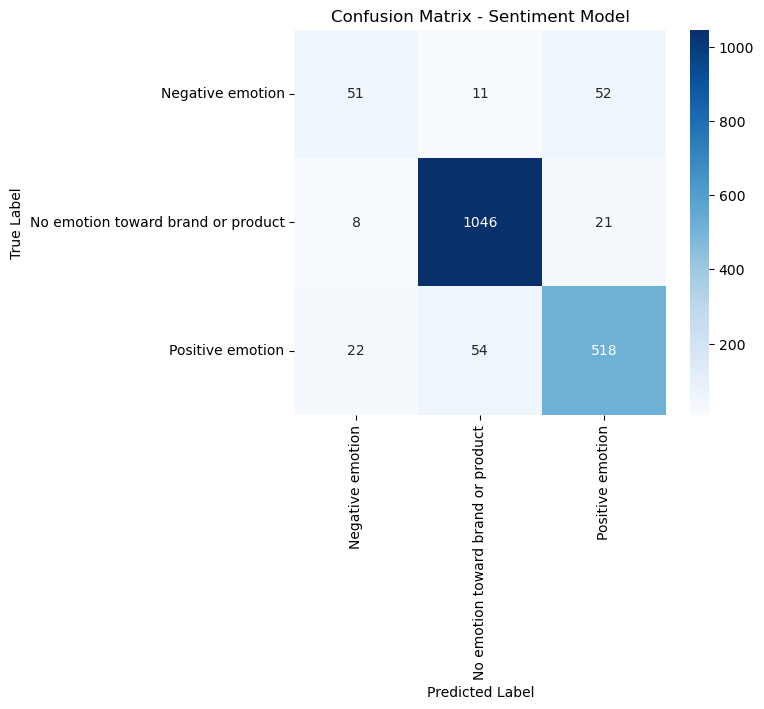

In [136]:
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Sentiment Model")
plt.show()

Confusion Matrix Interpretation
#### Negative Emotion (Weakest Class)
* Correct predictions: 51
* Misclassified as neutral: 11
* Misclassified as positive: 52
  * More negative tweets are being confused as positive (52) than correctly classified (51)

#### No Emotion (Strong Class)
* Correct predictions: 1046
* Misclassified as negative: 8
* Misclassified as positive: 21
   * Very strong performance
   * Model is highly confident in neutral classification
#### Positive Emotion (Good Performance)
* Correct predictions: 518
* Misclassified as negative: 22
* Misclassified as neutral: 54
   * Some confusion with neutral tweets
   * Some overlap in vocabulary between neutral and positive sentiment
   
The confusion matrix shows that while the model handles neutral and positive classes effectively, it has difficulty identifying negative sentiment. Many negative tweets are incorrectly labeled as positive or neutral, pointing to semantic overlap in the feature space and lingering effects of class imbalance—even after applying class weighting and hyperparameter tuning.

### Feature Importances

In [137]:
feature_names = model.named_steps['preprocess'].get_feature_names_out()
feature_names

array(['text__00', 'text__000', 'text__00am', ...,
       'brand__target_brand_apple', 'brand__target_brand_google',
       'brand__target_brand_other'], shape=(5003,), dtype=object)

In [138]:
# Get the coefficients from the trained model
coefs = model.named_steps['clf'].coef_[0]

importance_df = pd.DataFrame({
    'feature': feature_names,
    'weight': coefs
})

importance_df['abs_weight'] = importance_df['weight'].abs()
importance_df = importance_df.sort_values('abs_weight', ascending=False)

In [139]:
text_imp = importance_df[importance_df['feature'].str.startswith('text__')]
brand_imp = importance_df[importance_df['feature'].str.startswith('brand__')]

In [140]:
print(text_imp.head(10))
print(brand_imp.head(10))

              feature    weight  abs_weight
2524       text__link -2.374253    2.374253
1499       text__fail  1.790791    1.790791
1905  text__headaches  1.668996    1.668996
1895       text__hate  1.458717    1.458717
2591       text__long  1.422101    1.422101
3301      text__party -1.291870    1.291870
1644       text__free -1.269358    1.269358
974        text__cool -1.191707    1.191707
472     text__battery  1.157498    1.157498
2852    text__mention -1.151870    1.151870
                         feature    weight  abs_weight
5002   brand__target_brand_other -1.367125    1.367125
5000   brand__target_brand_apple  0.703366    0.703366
5001  brand__target_brand_google  0.588639    0.588639


In [145]:
importance_df = importance_df.rename(columns={'weight': 'importance'})

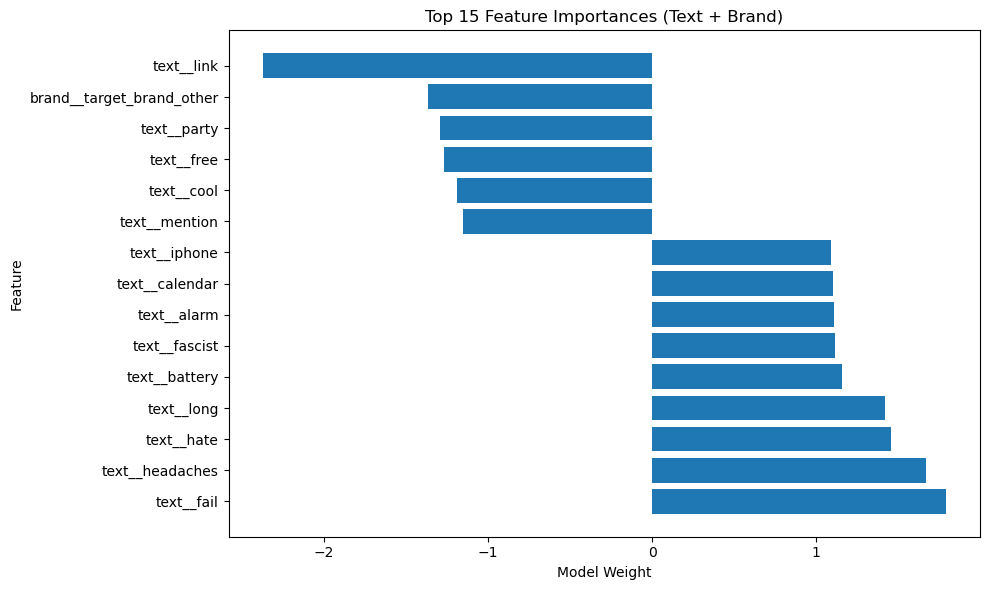

In [146]:
top_features = importance_df.head(15).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(top_features['feature'], top_features['importance'])
plt.title("Top 15 Feature Importances (Text + Brand)")
plt.xlabel("Model Weight")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The model is not assigning universal sentiment polarity to words. Instead, it is learning associations between words and class probabilities within your specific dataset distribution. That means a word like “fail” might strongly signal the Negative emotion class, while “cool” might push predictions toward Positive emotion or even Neutral, depending on how it appears in the training data.

In [171]:
lime_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000))
])

In [172]:
lime_model.fit(X_train['clean_tweet'], y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [184]:
from lime.lime_text import LimeTextExplainer

class_names = lime_model.named_steps['clf'].classes_
explainer = LimeTextExplainer(class_names=class_names)
def predict_proba(texts):
    return lime_model.predict_proba(texts)
i = 10
text_instance = X_test['clean_tweet'].iloc[i]
exp = explainer.explain_instance(
    text_instance,
    predict_proba,
    num_features=10
)


In [185]:
from IPython.display import HTML, display

display(HTML(exp.as_html()))

Although the tweet describes a potentially positive real-world situation (long queues at the Apple store indicating popularity), the model classifies it as neutral because it lacks explicit emotional keywords. LIME explanations show that predictions are driven more by contextual and descriptive terms (e.g., “Apple”, “sxsw”, “store”) than by sentiment-bearing words. This highlights a limitation of bag-of-words models in capturing implicit sentiment.

## Model Comparison

8. Evaluation

Performance was evaluated using:

Precision
Recall
F1-score
Confusion Matrix
Why F1-score?

The dataset contains class imbalance, meaning accuracy alone may provide misleading results.

F1-score balances:

F1=
Precision+Recall
2(Precision×Recall)
	​


F1=
Precision+Recall
2(Precision×Recall)
	​


A higher F1-score indicates better performance in correctly identifying sentiment classes.

9. Results

(Replace with your actual model results after running the notebook.)

Model	Precision	Recall	F1 Score
Logistic Regression	XX	XX	XX
Naive Bayes	XX	XX	XX
SVM	XX	XX	XX
Best Performing Model

The best-performing model was Logistic Regression/SVM (depending on your results), achieving the highest F1-score on the test dataset.

## Multiclass Classification Extension

10. Insights

The model identified several recurring sentiment indicators.

Common Positive Terms
love
great
awesome
excellent
amazing
Common Negative Terms
crash
issue
bad
broken
problem

These findings suggest that customers express positive sentiment when discussing product quality and user experience, while negative sentiment is often associated with technical issues and software failures.

1. Conclusion

This project successfully demonstrated the use of Natural Language Processing and machine learning techniques for sentiment classification of tweets related to Apple and Google products.

The combination of TF-IDF vectorization and machine learning algorithms provided an effective approach for transforming unstructured text into meaningful business insights.

The results indicate that automated sentiment analysis can support organizations in monitoring public opinion and identifying emerging customer concerns in real time.

12. Recommendations

Based on the findings, organizations should:

Monitor negative sentiment continuously to identify product issues.
Track sentiment trends following product launches.
Use sentiment analytics to support customer experience initiatives.
Incorporate more advanced NLP models such as:
BERT
Transformer-based architectures
Deep learning sentiment classifiers
Future Work

Future improvements could include:

Hyperparameter tuning.
Class imbalance handling using SMOTE.
Incorporating emoji sentiment.
Aspect-based sentiment analysis.
Real-time Twitter sentiment dashboards